BrainScan – Détection du Cancer Cérébral par CNN


Importer les bibliothèques (NumPy, OpenCV, TensorFlow, Matplotlib, etc.).

In [1]:
import math
import shutil
import os
import matplotlib.pyplot as plt
# import imutils
import glob
import  numpy as np
import cv2
import pandas as pd
import sns

DATA_PATH = "C:\\Users\\boume\\Briefs\\BrainScan\\Data"


Charger et vérifier les extensions d’images (jpeg, jpg, bmp, png).

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
Keras version: 3.11.3
Built with CUDA: False
GPU devices: []


In [3]:
folders = os.listdir(DATA_PATH)
for folder in folders :
    FOLDER_PATH = DATA_PATH+"//"+folder
    fichiers = os.listdir(FOLDER_PATH)
    for fichier in fichiers :
        FILE_PATH = DATA_PATH+"//"+folder+"//"+fichier
        f = fichier.split('.')
        if(f[1] != 'jpg' and f[1] != 'jpeg' and  f[1] != 'bmp' and f[1] != 'pnf') :
            os.remove(FILE_PATH)

In [4]:
folders = os.listdir(DATA_PATH)
for folder in folders :
    FOLDER_PATH = DATA_PATH+"//"+folder
    fichiers = os.listdir(FOLDER_PATH)
    for fichier in fichiers :
        FILE_PATH = DATA_PATH+"//"+folder+"//"+fichier
        if fichier.endswith(('.jpg','.jpeg','.bmp','.pnf')):
            pass
        else :
            os.remove(FILE_PATH)

Gérer les erreurs avec try-except.

In [5]:
folders = os.listdir(DATA_PATH)
for folder in folders :
    FOLDER_PATH = DATA_PATH+"//"+folder
    fichiers = os.listdir(FOLDER_PATH)
    for fichier in fichiers :
        try:
            FILE_PATH = DATA_PATH+"//"+folder+"//"+fichier
            image_path = os.path.join(FOLDER_PATH,fichier)
            image = cv2.imread(FILE_PATH)
            if image is not None:
                print(f"Loaded image: {fichier}, Shape: {image.shape}")
        except:
            print('error lors de chargement de fichier :', fichier)




Loaded image: glioma_0000.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0001.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0002.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0003.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0004.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0005.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0006.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0007.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0008.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0009.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0010.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0011.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0012.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0013.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0014.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0015.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0016.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0017.jpg, Shape: (224, 224, 3)
Loaded image: glioma_0018.jpg, Shape: (224, 224, 3)
Loaded image

Explorer et afficher les classes du dataset.

In [6]:
for folder in folders :
    print(folder)

glioma
meningioma
notumor
pituitary


Créer deux listes synchronisées (images / labels).

In [7]:
labels = []
images = []

folders = os.listdir(DATA_PATH)
for folder in folders :
    FOLDER_PATH = DATA_PATH+"//"+folder
    fichiers = os.listdir(FOLDER_PATH)

    for fichier in fichiers :

        try:
            FILE_PATH = DATA_PATH+"//"+folder+"//"+fichier
            image_path = os.path.join(FOLDER_PATH,fichier)
            image = cv2.imread(FILE_PATH)
            stretch_near = cv2.resize(image, (224, 224), interpolation=cv2.INTER_LINEAR)

            labels.append(folder)
            images.append(stretch_near)
        except:
            print('error lors de chargement de fichier :', fichier)


In [8]:
labels[:5]

['glioma', 'glioma', 'glioma', 'glioma', 'glioma']

In [9]:
images[:5]


[array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]]], shape=(224, 224, 3), dtype=uint8),
 array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0,

Convertir les listes en tableaux NumPy.

In [10]:
Images = np.array(images)
Labels = np.array(labels)
len(Images)

8000

Visualiser la distribution des classes et appliquer un rééquilibrage si nécessaire.

(array([2000.,    0.,    0., 2000.,    0.,    0., 2000.,    0.,    0.,
        2000.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

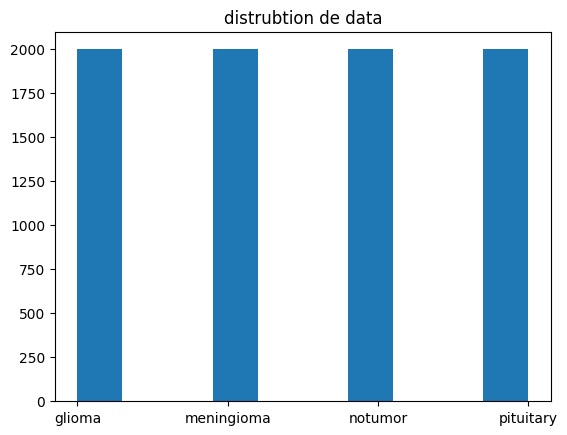

In [11]:
plt.title('distrubtion de data')
plt.hist(Labels)

rééquilibrage


In [12]:
import numpy
import random
lbls,counts = numpy.unique(Labels, return_counts=True)
info =dict(zip(lbls, counts))
info_clean = {str(k): int(v) for k, v in info.items()}
INDEX_BEFORE_ADD_IMAGES = len(Labels)
EquilibredImages = np.array([])
EquilibredLabels = np.array([])
def ImagesEquilibre (ELabels,EImages,index):

    if index < INDEX_BEFORE_ADD_IMAGES:
        lbl = Labels[index]
        print(lbl)
        count = info_clean[lbl]
        newImages = []
        newLibales = []
        if count < 2000 :
            number_of_copy = 2000 - count
            print(number_of_copy)
            for i in range (0 , number_of_copy):
                index_of_filter = random.randint(0,1)
                filters = [cv2.medianBlur(Images[i], 5),cv2.flip(Images[i],1)]

                median_blurred = filters[index_of_filter]
                cv2.imwrite(os.path.join("Data/"+lbl, f"{lbl}_{i:04d}.jpg"), Images[i])

                newImages.append(median_blurred)
                newLibales.append(lbl)
        NewImgs = np.array(newImages)
        NewLbs = np.array(newLibales)
        EImages = list(EImages) + list(NewImgs)
        ELabels = list(ELabels) + list(NewLbs)
        index = index +  count
        print("newLibales  :",len(newLibales))
        print("EquilibreLabel  :",len(ELabels))
        return ImagesEquilibre(ELabels,EImages,index)
    return np.array(ELabels) , np.array(EImages)

nLabels , nImages = ImagesEquilibre(Labels , Images , 0)
print("labels are :",len(nLabels))


glioma
newLibales  : 0
EquilibreLabel  : 8000
meningioma
newLibales  : 0
EquilibreLabel  : 8000
notumor
newLibales  : 0
EquilibreLabel  : 8000
pituitary
newLibales  : 0
EquilibreLabel  : 8000
labels are : 8000


In [13]:
len(nLabels)

8000

(array([2000.,    0.,    0., 2000.,    0.,    0., 2000.,    0.,    0.,
        2000.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

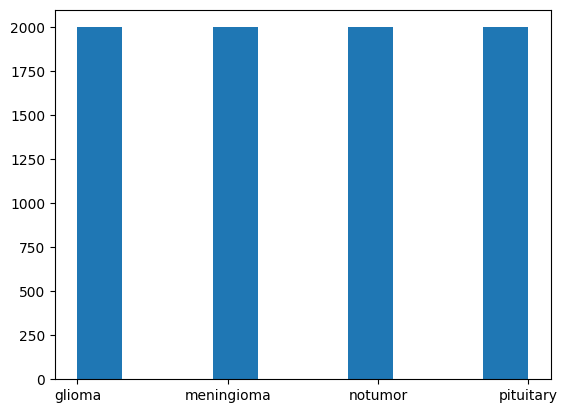

In [14]:
plt.hist(nLabels)

Encoder les labels (LabelEncoder / to_categorical).

In [15]:
df_labels = pd.DataFrame(data =nLabels , columns=["labels"])

In [16]:
df_labels_encoded = pd.get_dummies(df_labels, columns=["labels"])

In [17]:
df_labels_encoded

,labels_glioma,labels_meningioma,labels_notumor,labels_pituitary
0,True,False,False,False
1,True,False,False,False
2,True,False,False,False
3,True,False,False,False
4,True,False,False,False
...,...,...,...,...
7995,False,False,False,True
7996,False,False,False,True
7997,False,False,False,True
7998,False,False,False,True


Diviser en train/test (ex. 80/20).

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    nImages, df_labels_encoded, test_size=0.2, random_state=42, stratify=nLabels
)

print("Train images:", X_train.shape)
print("Test images:", X_test.shape)

Train images: (6400, 224, 224, 3)
Test images: (1600, 224, 224, 3)


Normaliser les valeurs de pixels [0, 1].

In [19]:
X_train_scaled = X_train/ 255
X_test_scaled = X_test/ 255

Définir l’architecture CNN (Conv2D, MaxPooling2D, Flatten, Dropout, Dense).

In [20]:
print(X_train.shape)
print(X_train.dtype)

(6400, 224, 224, 3)
uint8


In [21]:
from keras.src.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu',  input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(512, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Dropout(0.5),
    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(4,activation='softmax')

])
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

C:\Users\boume\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,207,620 (12.24 MB)

 Trainable params: 3,207,620 (12.24 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import sys
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs: []


In [23]:
import keras
import time
start = time.time()
EPOCHS =  25
checkpoint_filepath = 'checkpoints/model7/checkpoint_epoch_{epoch:02d}.model.keras'

model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=False,
    save_weights_only=False,
    verbose=1
)

history = model.fit(
        X_train_scaled,
        y_train,
        batch_size=16,
        epochs=EPOCHS,
        validation_split= 0.5,
        callbacks = [model_checkpoint_callback]
    )

end = time.time()
print("Temps total d'entraînement :", (end - start)/60, "minutes")


Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.4653 - loss: 1.1388
Epoch 1: saving model to checkpoints/model7/checkpoint_epoch_01.model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 148s 713ms/step - accuracy: 0.5894 - loss: 0.9582 - val_accuracy: 0.7300 - val_loss: 0.7241
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.7107 - loss: 0.7315
Epoch 2: saving model to checkpoints/model7/checkpoint_epoch_02.model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 93s 468ms/step - accuracy: 0.7181 - loss: 0.7096 - val_accuracy: 0.7491 - val_loss: 0.6738
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7667 - loss: 0.6068
Epoch 3: saving model to checkpoints/model7/checkpoint_epoch_03.model.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 94s 473ms/step - accuracy: 0.7769 - loss: 0.5788 - val_accuracy: 0.7978 - val_loss: 0.5450
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.8175 - loss: 0.4854
Epoch 4: saving model to checkpoints/model7/checkpoint_epoc

In [24]:
loss, accuracy = model.evaluate(X_test_scaled, y_test , batch_size  = 32)
print(f" Perte (loss) sur le test : {loss:.4f}")
print(f" Précision (accuracy) sur le test : {accuracy*100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.8656 - loss: 0.7016
 Perte (loss) sur le test : 0.7016
 Précision (accuracy) sur le test : 86.56%


In [25]:
model.save("models/model_complete7.keras")

In [26]:
from tensorflow.keras.models import load_model

hist  = load_model("models/model_complete7.keras")


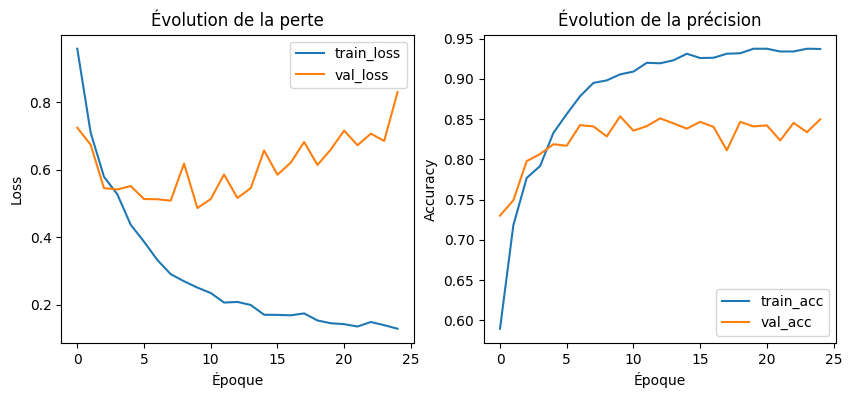

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Évolution de la perte')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Évolution de la précision')
plt.xlabel('Époque')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [28]:
import tensorflow as tf
import sys
import tensorflow

# Find where this broken tensorflow is
print("TensorFlow path:", tensorflow.__path__)
print("TensorFlow spec:", tensorflow.__spec__)

# Remove from sys.modules
if 'tensorflow' in sys.modules:
    del sys.modules['tensorflow']

if tf.config.list_physical_devices('GPU'):
    print("\nGPU Details:")
    for gpu in tf.config.list_physical_devices('GPU'):
        print(gpu)

    print("\nBuilt with CUDA:", tf.test.is_built_with_cuda())
    print("GPU available:", tf.test.is_gpu_available())

TensorFlow path: ['C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\keras\\api\\_v2', 'C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\keras\\_tf_keras', 'C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow', 'C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow\\_api\\v2']
TensorFlow spec: ModuleSpec(name='tensorflow', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001E0FFEC83B0>, origin='C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow\\__init__.py', submodule_search_locations=['C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow', 'C:\\Users\\boume\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\tensorflow\\_api\\v2'])


In [29]:
import shutil
import os

tf_path = r"C:\Users\boume\Briefs\BrainScan\.venv\Lib\site-packages\tensorflow"

if os.path.exists(tf_path):
    try:
        shutil.rmtree(tf_path)
        print(f"✓ Removed broken TensorFlow directory: {tf_path}")
    except Exception as e:
        print(f"Error: {e}")
        print("Try manually deleting the folder")


Génération des prédictions pour la matrice de confusion...
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step


Text(0.5, 58.7222222222222, 'Classe Prédite')

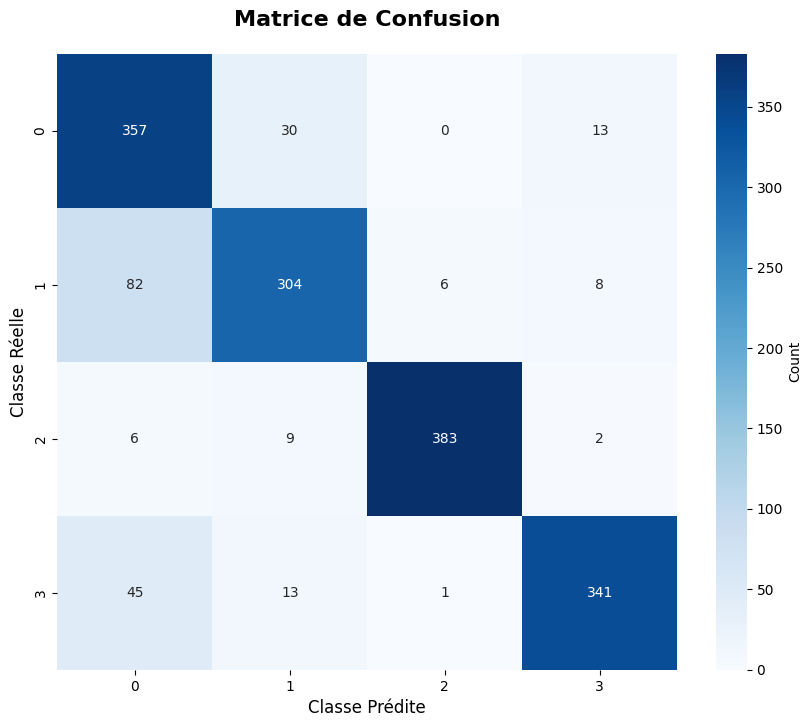

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


print("\nGénération des prédictions pour la matrice de confusion...")
y_pred = model.predict(X_test_scaled, batch_size=32)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title('Matrice de Confusion', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Classe Réelle', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)

# Add accuracy per class
